In [1]:
from metloom.pointdata import SnotelPointData
from datetime import datetime
import os
import glob
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scores.continuous import kge, nse
import matplotlib.dates as mdates
from functools import reduce
import numpy as np

# the os.environment command was used when I was having issues with my proj library. Delete if not needed
#os.environ['PROJ_DATA'] = "C:/Users/RDCRLSMC/AppData/Local/miniconda3/envs/SIRO/Library/share/proj"
import sys
sys.path.append('../scripts')
from model_comparison_functions import x_y_snotel

In [2]:
base_dir = "C:/Users/RDCRLSMC/Desktop/SIRO/publication_upload/"

##All HMS uploads are Task 1

TI_t1 = glob.glob(os.path.join(base_dir, "1_TI/TI_Task1/", "*.nc"))
TI_t2 = glob.glob(os.path.join(base_dir, "1_TI/TI_Task2/", "*.nc"))

EB_t1 = glob.glob(os.path.join(base_dir, "2_EB/EB_Task1/", "*.nc"))
EB_t2 = glob.glob(os.path.join(base_dir, "2_EB/EB_Task2/", "*.nc"))

iSno_t1 = glob.glob(os.path.join(base_dir, "3_iSnobal/Task1/", "*.nc"))
iSno_t2 = glob.glob(os.path.join(base_dir, "3_iSnobal/Task2/", "*.nc"))

SM_t1 = glob.glob(os.path.join(base_dir, "4_SM/Task1", "*.nc"))
SM_t2 = glob.glob(os.path.join(base_dir, "4_SM/Task2/", "*.nc"))


In [3]:
snotel_point_MCS = SnotelPointData("637:ID:SNTL", "MCS") # define the snotel ID
snotel_point_BB = SnotelPointData("978:ID:SNTL", "Bogus Basin") # define the snotel ID

MCS_SNOTEL = snotel_point_MCS.get_daily_data(
    datetime(2022, 10, 1), datetime(2025, 10, 1),
    [snotel_point_MCS.ALLOWED_VARIABLES.SNOWDEPTH])
    
BB_SNOTEL = snotel_point_BB.get_daily_data(
    datetime(2022, 10, 1), datetime(2025, 10, 1),
    [snotel_point_BB.ALLOWED_VARIABLES.SNOWDEPTH])  
MCS_SNOTEL["SNOWDEPTH (m)"] = MCS_SNOTEL["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
BB_SNOTEL["SNOWDEPTH (m)"] = BB_SNOTEL["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
MCS_SNOTEL = MCS_SNOTEL.reset_index()
BB_SNOTEL = BB_SNOTEL.reset_index()

MCS_SNOTEL["date"] = MCS_SNOTEL["datetime"].dt.date
BB_SNOTEL["date"] = BB_SNOTEL["datetime"].dt.date

In [4]:
MCS = x_y_snotel(snotel_point_MCS)
BB = x_y_snotel(snotel_point_BB)

In [5]:
def build_timeseries_netcdf(filelist, modelname, point):

    dfs = []

    for file in filelist:
        ds = xr.open_dataset(file, engine = 'netcdf4')

        # select nearest grid point
        ts = ds['SD'].sel(
            x=point[0],
            y=point[1],
            method="nearest"
        )

        # convert to dataframe WITH time preserved
        df = ts.to_dataframe(name=modelname).reset_index()

        # keep only relevant columns
        dfs.append(df[['time', modelname]])

    # combine all files into one time series
    out = pd.concat(dfs, ignore_index=True)

    # optional: sort by time
    out = out.sort_values('time').reset_index(drop=True)

    return out

In [6]:
def build_and_prep(raw,  modelname, point):
    df = build_timeseries_netcdf(raw,  modelname, point)
    df["merge_date"] = pd.to_datetime(df["time"]).dt.date
    df = df.rename(columns={"time": f"time_{modelname}"})
    return df

EB_t1_MCS   = build_and_prep(EB_t1,   "HMS_EB_t1",     MCS)
TI_t1_MCS   = build_and_prep(TI_t1,   "HMS_TI_t1",     MCS)
SM_t1_MCS   = build_and_prep(SM_t1,   "SnowModel_t1",  MCS)
iSno_t1_MCS = build_and_prep(iSno_t1, "iSnobal_t1",    MCS)

EB_t2_MCS   = build_and_prep(EB_t2,   "HMS_EB_t2",     MCS)
TI_t2_MCS   = build_and_prep(TI_t2,   "HMS_TI_t2",     MCS)
SM_t2_MCS   = build_and_prep(SM_t2,   "SnowModel_t2",  MCS)
iSno_t2_MCS = build_and_prep(iSno_t2, "iSnobal_t2",    MCS)

df = [EB_t1_MCS, TI_t1_MCS, SM_t1_MCS, iSno_t1_MCS, EB_t2_MCS, TI_t2_MCS, SM_t2_MCS, iSno_t2_MCS]

df_merged = reduce(
    lambda left, right: pd.merge(left, right, on="merge_date", how="outer"),
    df)

In [7]:
for c in ["HMS_TI_t1","HMS_EB_t1","SnowModel_t1","HMS_TI_t2","HMS_EB_t2","SnowModel_t2"]:
    s = df_merged.set_index("merge_date")[c]
    fv, lv = s.first_valid_index(), s.last_valid_index()
    core = s.loc[fv:lv]
    nan_dates = list(pd.to_datetime(core[core.isna()].index).date)
    print(f"{c:14s} {fv} -> {lv}   NaNs ({len(nan_dates)}): {nan_dates}")

HMS_TI_t1      2022-10-02 -> 2025-05-30   NaNs (2): [datetime.date(2023, 7, 1), datetime.date(2024, 7, 1)]
HMS_EB_t1      2022-10-02 -> 2025-05-30   NaNs (2): [datetime.date(2023, 7, 1), datetime.date(2024, 7, 1)]
SnowModel_t1   2022-10-01 -> 2025-06-18   NaNs (3): [datetime.date(2023, 7, 1), datetime.date(2024, 6, 30), datetime.date(2024, 7, 1)]
HMS_TI_t2      2022-10-02 -> 2025-05-30   NaNs (2): [datetime.date(2023, 7, 1), datetime.date(2024, 7, 1)]
HMS_EB_t2      2022-10-02 -> 2025-05-30   NaNs (2): [datetime.date(2023, 7, 1), datetime.date(2024, 7, 1)]
SnowModel_t2   2022-10-01 -> 2025-06-18   NaNs (3): [datetime.date(2023, 7, 1), datetime.date(2024, 6, 30), datetime.date(2024, 7, 1)]


In [8]:
windows = [("2022-10-02","2023-06-30"),   # WY23
           ("2023-10-02","2024-06-30"),   # WY24
           ("2024-10-02","2025-05-30")]   # WY25 — stops at May 30

df_MCS = df_merged.rename(columns={"merge_date": "date"}).copy()
df_MCS["date"] = pd.to_datetime(df_MCS["date"])

keep = np.zeros(len(df_MCS), bool)
for s, e in windows:
    keep |= (df_MCS["date"] >= s) & (df_MCS["date"] <= e)
df_MCS = df_MCS[keep]

# SNOTEL 'date' is a python date; make it datetime so the merge keys match
snotel = MCS_SNOTEL[["date", "SNOWDEPTH (m)"]].copy()
snotel["date"] = pd.to_datetime(snotel["date"])

df_MCS = pd.merge(df_MCS, snotel, on="date", how="left")

df_MCS = df_MCS.set_index("date")           # set index once, at the end
MCS_ds = xr.Dataset.from_dataframe(df_MCS)

In [9]:

EB_t1_BB   = build_and_prep(EB_t1,   "HMS_EB_t1",     BB)
TI_t1_BB   = build_and_prep(TI_t1,   "HMS_TI_t1",     BB)
SM_t1_BB   = build_and_prep(SM_t1,   "SnowModel_t1",  BB)
iSno_t1_BB = build_and_prep(iSno_t1, "iSnobal_t1",    BB)

EB_t2_BB   = build_and_prep(EB_t2,   "HMS_EB_t2",     BB)
TI_t2_BB   = build_and_prep(TI_t2,   "HMS_TI_t2",     BB)
SM_t2_BB   = build_and_prep(SM_t2,   "SnowModel_t2",  BB)
iSno_t2_BB = build_and_prep(iSno_t2, "iSnobal_t2",    BB)

df_bb = [EB_t1_BB, TI_t1_BB, SM_t1_BB, iSno_t1_BB, EB_t2_BB, TI_t2_BB, SM_t2_BB, iSno_t2_BB]

df_merged_bb = reduce(
    lambda left, right: pd.merge(left, right, on="merge_date", how="outer"),
    df_bb)

In [19]:
windows = [("2022-10-02","2023-06-30"),   # WY23
           ("2023-10-02","2024-06-30"),   # WY24
           ("2024-10-02","2025-05-30")]   # WY25 — stops at May 30

df_BB = df_merged_bb.rename(columns={"merge_date": "date"}).copy()
df_BB["date"] = pd.to_datetime(df_BB["date"])

keep = np.zeros(len(df_BB), bool)
for s, e in windows:
    keep |= (df_BB["date"] >= s) & (df_BB["date"] <= e)
df_BB = df_BB[keep]

# SNOTEL 'date' is a python date; make it datetime so the merge keys match
snotel = BB_SNOTEL[["date", "SNOWDEPTH (m)"]].copy()
snotel["date"] = pd.to_datetime(snotel["date"])

df_BB = pd.merge(df_BB, snotel, on="date", how="left")

df_BB = df_BB.set_index("date")           # set index once, at the end
bb_ds = xr.Dataset.from_dataframe(df_BB)

In [11]:
obs = MCS_ds['SNOWDEPTH (m)']
fcst1_a = MCS_ds['HMS_TI_t1']
fcst1_b = MCS_ds['HMS_TI_t2']

fcst2_a = MCS_ds['HMS_EB_t1']
fcst2_b = MCS_ds['HMS_EB_t2']

fcst3_a = MCS_ds['SnowModel_t1']
fcst3_b = MCS_ds['SnowModel_t2']

fcst4_a = MCS_ds['iSnobal_t1']
fcst4_b = MCS_ds['iSnobal_t2']

forecasts = [
    ("Temperature Index", fcst1_a, fcst1_b),
    ("Energy Balance", fcst2_a, fcst2_b),
    ("SnowModel", fcst3_a, fcst3_b),
    ("iSnobal", fcst4_a, fcst4_b),
]

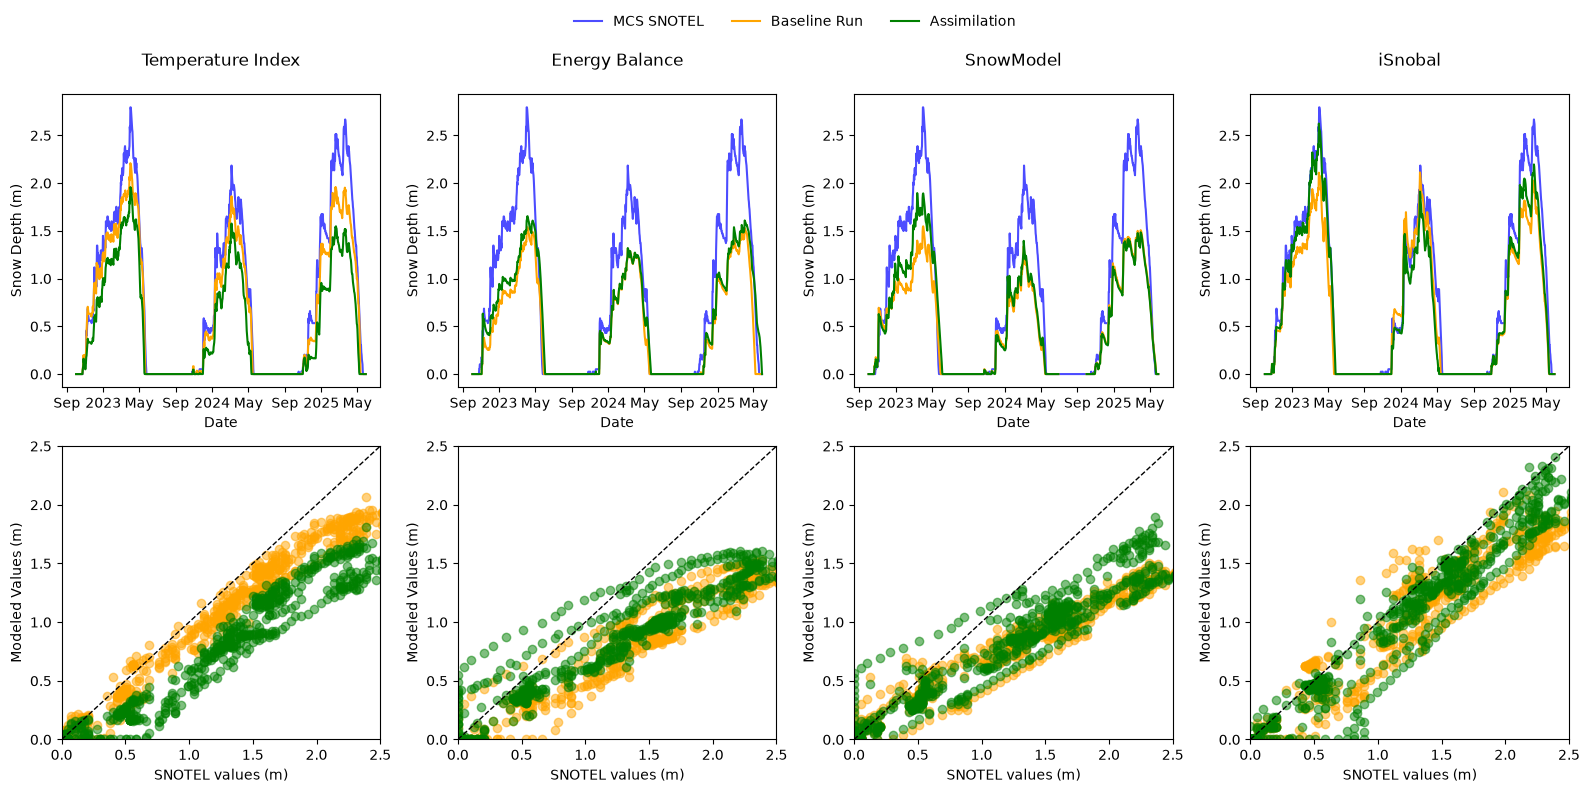

In [13]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))

for i, (name, fcst_a, fcst_b) in enumerate(forecasts):

    obs.plot(ax=axs[0, i], label="MCS SNOTEL", color="blue", alpha=0.7)
    fcst_a.plot(ax=axs[0, i], label="Baseline Run", color="orange")
    fcst_b.plot(ax=axs[0, i], label="Assimilation", color="green")

    axs[0, i].set_ylabel("Snow Depth (m)")
    axs[0, i].set_xlabel("Date")
    # axs[0, i].legend()  # removed — using shared legend instead

    # Scatter plot
    axs[1, i].scatter(
        obs.values,
        fcst_a.values,
        label="Baseline Run",
        alpha=0.5,
        color='orange'
    )

    axs[1, i].scatter(
        obs.values,
        fcst_b.values,
        label="Assimilation",
        alpha=0.5,
        color='green'
    )

    axs[1, i].plot(
        [0, 2.5],
        [0, 2.5],
        color="black",
        linestyle="--",
        linewidth=1
    )

    # axs[1, i].legend()  # removed — using shared legend instead

    axs[1, i].set_xlabel("SNOTEL values (m)")
    axs[1, i].set_ylabel("Modeled Values (m)")
    axs[1, i].set_xlim(0, 2.5)
    axs[1, i].set_ylim(0, 2.5)

    kge1 = kge(fcst_a, obs, include_components=True)
    kge2 = kge(fcst_b, obs, include_components=True)

    axs[0, i].set_title(
        f"{name}\n"
    )

# First, fix layout and carve out explicit vertical space
plt.tight_layout()
fig.subplots_adjust(top=0.88, hspace=0.20)  # hspace = gap between row 0 and row 1

# Get row boundary in figure coordinates AFTER layout is finalized
row0_bottom = axs[0, 0].get_position().y0   # bottom edge of row 0
row1_top = axs[1, 0].get_position().y1      # top edge of row 1
gap_center = (row0_bottom + row1_top) / 2   # midpoint of the gap between rows

# Shared legend for row 0 (time series plots) — above row 0
handles0, labels0 = axs[0, 0].get_legend_handles_labels()
fig.legend(handles0, labels0, loc='center', ncol=3,
           bbox_to_anchor=(0.5, 0.97), frameon=False)

# Shared legend for row 1 (scatter plots) — in the gap between rows
# handles1, labels1 = axs[1, 0].get_legend_handles_labels()
# fig.legend(handles1, labels1, loc='center', ncol=2,
#            bbox_to_anchor=(0.5, gap_center), frameon=False)

#plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/KGE_MCS_legend.png', dpi=300)
plt.show()

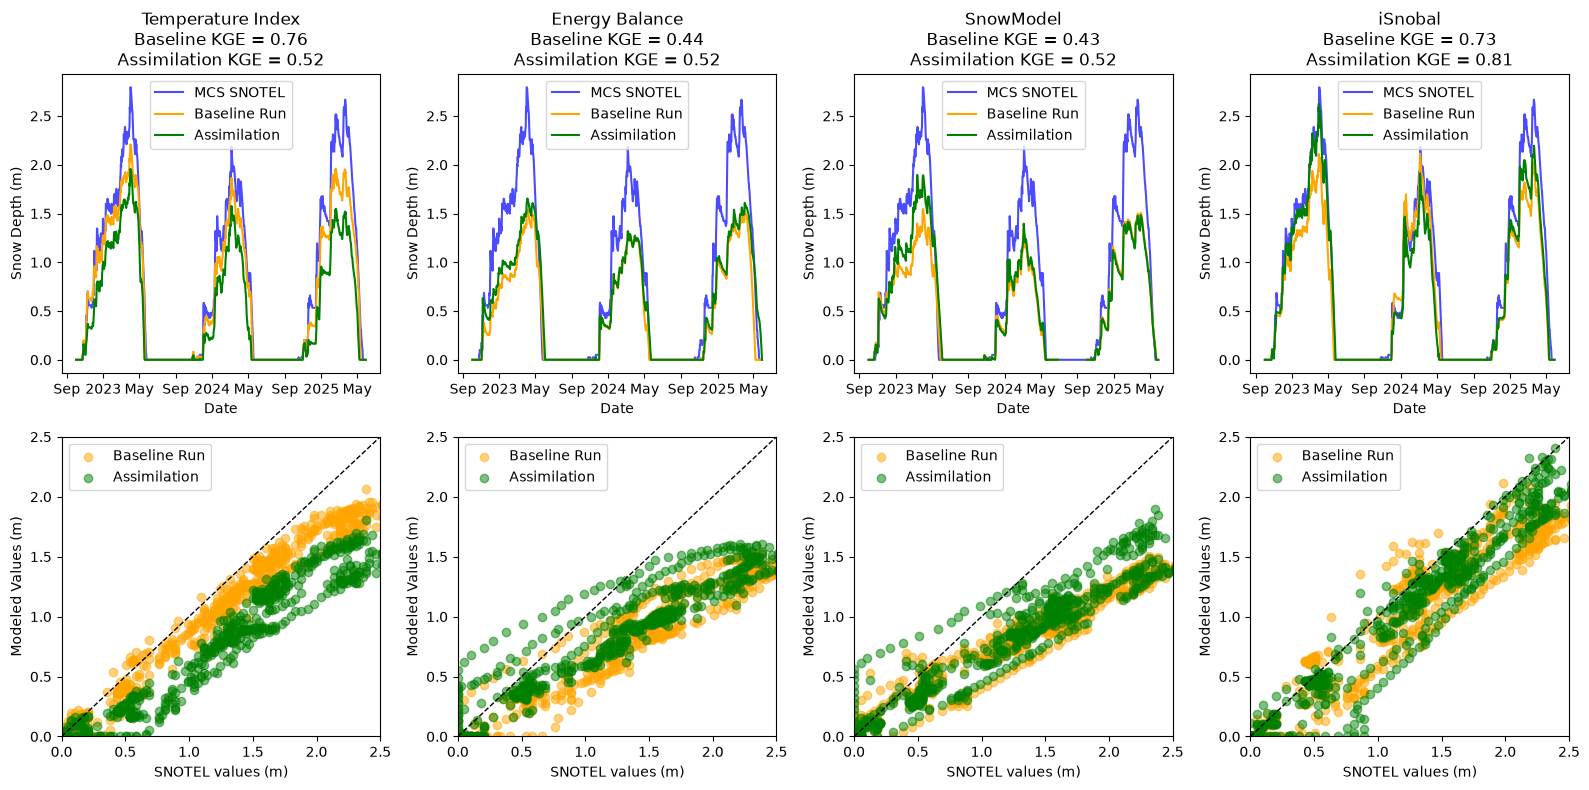

In [14]:
##Plots for MCS

fig, axs = plt.subplots(2, 4, figsize=(16, 8))

for i, (name, fcst_a, fcst_b) in enumerate(forecasts):

    obs.plot(ax=axs[0, i], label="MCS SNOTEL", color = "blue", alpha=0.7)
    fcst_a.plot(ax=axs[0, i], label="Baseline Run", color = "orange")
    fcst_b.plot(ax=axs[0, i], label="Assimilation", color = "green")

    axs[0, i].set_ylabel("Snow Depth (m)")
    axs[0, i].set_xlabel("Date")
    axs[0, i].legend()
   #axs[0, i].set_title(name)

    # Scatter plot

    axs[1, i].scatter(
    obs.values,
    fcst_a.values,
    label="Baseline Run",
    alpha=0.5,
    color = 'orange'
    )

    axs[1, i].scatter(
        obs.values,
        fcst_b.values,
        label="Assimilation",
        alpha=0.5,
        color = 'green'
    )

    axs[1, i].plot(
    [0, 2.5],
    [0, 2.5],
    color="black",
    linestyle="--",
    linewidth=1
    )

    axs[1, i].legend()

    axs[1, i].set_xlabel("SNOTEL values (m)")
    axs[1, i].set_ylabel(f"Modeled Values (m)")
    axs[1, i].set_xlim(0, 2.5)
    axs[1, i].set_ylim(0, 2.5)


    # obs_vals = obs.values.flatten()
    # fcst_a_vals = fcst_a.values.flatten()
    # fcst_b_vals = fcst_b.values.flatten()
    #
    kge1 = kge(fcst_a, obs, include_components=True)
    kge2 = kge(fcst_b, obs, include_components=True)

    axs[0, i].set_title(
    f"{name}\n"
    f"Baseline KGE = {kge1['kge'].item():.2f}\n"
    f"Assimilation KGE = {kge2['kge'].item():.2f}"
)

plt.tight_layout()
#plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/KGE_MCS.png', dpi = 300)
plt.show()

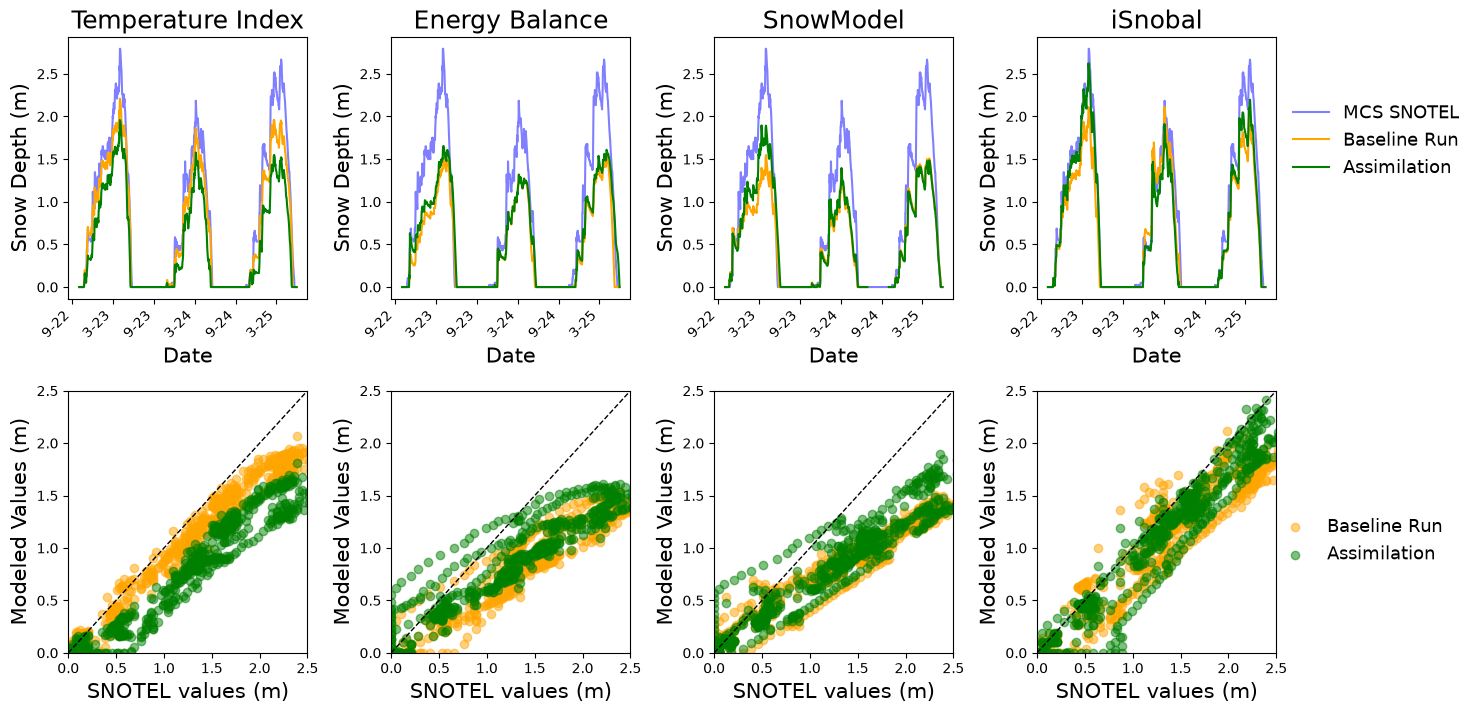

In [15]:

fig, axs = plt.subplots(2, 4, figsize=(16, 8))

for i, (name, fcst_a, fcst_b) in enumerate(forecasts):

    obs.plot(ax=axs[0, i], label="MCS SNOTEL", color="blue", alpha=0.5)
    fcst_a.plot(ax=axs[0, i], label="Baseline Run", color="orange")
    fcst_b.plot(ax=axs[0, i], label="Assimilation", color="green")

    axs[0, i].set_ylabel("Snow Depth (m)", fontsize=15)
    axs[0, i].set_xlabel("Date", fontsize=15)
    axs[0, i].xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # tick every 2 months
    axs[0, i].xaxis.set_major_formatter(mdates.DateFormatter('%#m-%y'))

    for label in axs[0, i].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

    axs[1, i].scatter(obs.values, fcst_a.values, label="Baseline Run", alpha=0.5, color='orange')
    axs[1, i].scatter(obs.values, fcst_b.values, label="Assimilation", alpha=0.5, color='green')
    axs[1, i].plot([0, 2.5], [0, 2.5], color="black", linestyle="--", linewidth=1)

    axs[1, i].set_xlabel("SNOTEL values (m)", fontsize=15)
    axs[1, i].set_ylabel("Modeled Values (m)", fontsize=15)
    axs[1, i].set_xlim(0, 2.5)
    axs[1, i].set_ylim(0, 2.5)

    kge1 = kge(fcst_a, obs, include_components=True)
    kge2 = kge(fcst_b, obs, include_components=True)

    axs[0, i].set_title(f"{name}", fontsize=18)

# Use subplots_adjust instead of tight_layout to leave room on the right
fig.subplots_adjust(right=0.88, wspace=0.35, hspace=0.35)

# Capture the legend objects so we can pass them to savefig
handles0, labels0 = axs[0, -1].get_legend_handles_labels()
leg0 = fig.legend(handles0, labels0, loc='center left',
                   bbox_to_anchor=(0.88, 0.75), fontsize=13, frameon=False)

handles1, labels1 = axs[1, -1].get_legend_handles_labels()
leg1 = fig.legend(handles1, labels1, loc='center left',
                   bbox_to_anchor=(0.870, 0.25), fontsize=13, frameon=False)

# plt.savefig(
#     'C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/KGE_MCSpresentation.png',
#     dpi=300,
#     bbox_inches='tight',
#     bbox_extra_artists=(leg0, leg1)
# )
plt.show()

In [16]:
rows_list = []

for i, (name, fcst_a, fcst_b) in enumerate(forecasts):

    kge1 = kge(fcst_a, obs, include_components=True)
    kge2 = kge(fcst_b, obs, include_components=True)

    nse1 = nse(fcst_a, obs)
    nse2 = nse(fcst_b, obs)

    rows_list.append({
        "Model Run": name,
        "Baseline KGE": f"{kge1['kge'].item():.3f}",
        "Assimilation KGE": f"{kge2['kge'].item():.3f}",
        "Baseline NSE": f"{nse1.item():.3f}",
        "Assimilation NSE": f"{nse2.item():.3f}",
        "Baseline bias": f"{kge1['beta'].item():.3f}",
        "Assimilation bias": f"{kge2['beta'].item():.3f}",
    })

stats_df = pd.DataFrame(rows_list)
print(stats_df)

           Model Run Baseline KGE Assimilation KGE Baseline NSE  \
0  Temperature Index        0.763            0.517        0.916   
1     Energy Balance        0.439            0.518        0.586   
2          SnowModel        0.429            0.521        0.586   
3            iSnobal        0.726            0.813        0.861   

  Assimilation NSE Baseline bias Assimilation bias  
0            0.675         0.835             0.628  
1            0.676         0.595             0.680  
2            0.681         0.612             0.670  
3            0.917         0.803             0.847  


In [17]:
stats_df

,Model Run,Baseline KGE,Assimilation KGE,Baseline NSE,Assimilation NSE,Baseline bias,Assimilation bias
0,Temperature Index,0.763,0.517,0.916,0.675,0.835,0.628
1,Energy Balance,0.439,0.518,0.586,0.676,0.595,0.680
2,SnowModel,0.429,0.521,0.586,0.681,0.612,0.670
3,iSnobal,0.726,0.813,0.861,0.917,0.803,0.847


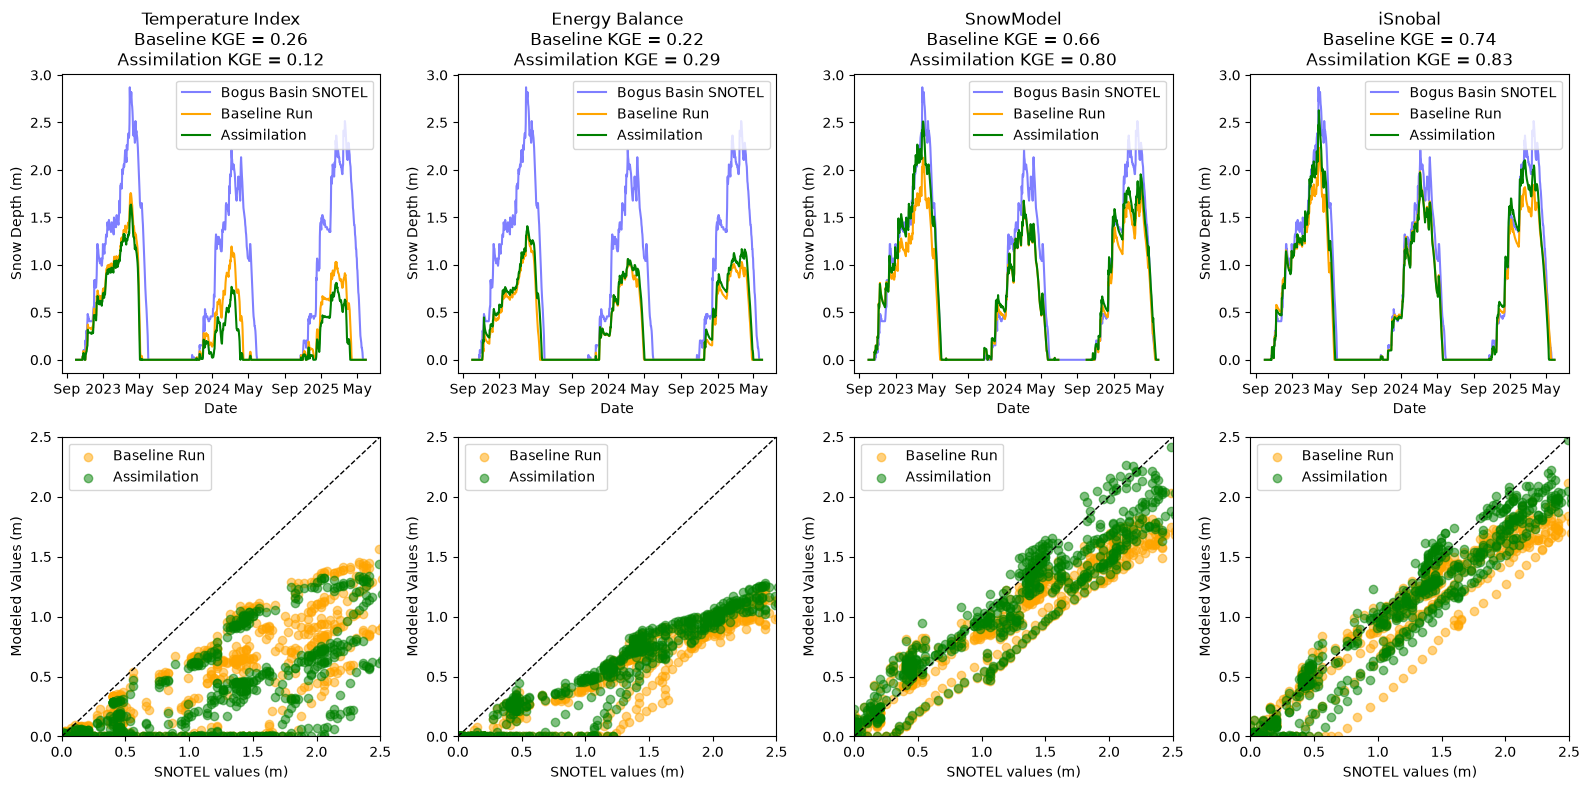

In [20]:
##Plots for MCS
obs = bb_ds['SNOWDEPTH (m)']
fcst1_a = bb_ds['HMS_TI_t1']
fcst1_b = bb_ds['HMS_TI_t2']

fcst2_a = bb_ds['HMS_EB_t1']
fcst2_b = bb_ds['HMS_EB_t2']

fcst3_a = bb_ds['SnowModel_t1']
fcst3_b = bb_ds['SnowModel_t2']

fcst4_a = bb_ds['iSnobal_t1']
fcst4_b = bb_ds['iSnobal_t2']

forecasts = [
    ("Temperature Index", fcst1_a, fcst1_b),
    ("Energy Balance", fcst2_a, fcst2_b),
    ("SnowModel", fcst3_a, fcst3_b),
    ("iSnobal", fcst4_a, fcst4_b),
]

fig, axs = plt.subplots(2, 4, figsize=(16, 8))

for i, (name, fcst_a, fcst_b) in enumerate(forecasts):

    obs.plot(ax=axs[0, i], label="Bogus Basin SNOTEL", color = "blue", alpha=0.5)
    fcst_a.plot(ax=axs[0, i], label="Baseline Run", color = "orange")
    fcst_b.plot(ax=axs[0, i], label="Assimilation", color = 'green')

    axs[0, i].set_ylabel("Snow Depth (m)")
    axs[0, i].set_xlabel("Date")
    axs[0, i].legend()
   #axs[0, i].set_title(name)

    # Scatter plot

    axs[1, i].scatter(
    obs.values,
    fcst_a.values,
    label="Baseline Run",
    alpha=0.5,
    color = 'orange'
    )

    axs[1, i].scatter(
        obs.values,
        fcst_b.values,
        label="Assimilation",
        alpha=0.5,
        color = 'green'
    )

    axs[1, i].plot(
    [0, 2.5],
    [0, 2.5],
    color="black",
    linestyle="--",
    linewidth=1
    )

    axs[1, i].legend()

    axs[1, i].set_xlabel("SNOTEL values (m)")
    axs[1, i].set_ylabel(f"Modeled Values (m)")
    axs[1, i].set_xlim(0, 2.5)
    axs[1, i].set_ylim(0, 2.5)


    # obs_vals = obs.values.flatten()
    # fcst_a_vals = fcst_a.values.flatten()
    # fcst_b_vals = fcst_b.values.flatten()
    #
    kge1 = kge(fcst_a, obs, include_components=True)
    kge2 = kge(fcst_b, obs, include_components=True)

    axs[0, i].set_title(
    f"{name}\n"
    f"Baseline KGE = {kge1['kge'].item():.2f}\n"
    f"Assimilation KGE = {kge2['kge'].item():.2f}"
)

plt.tight_layout()
#plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/KGE_BB.png', dpi = 300)
plt.show()

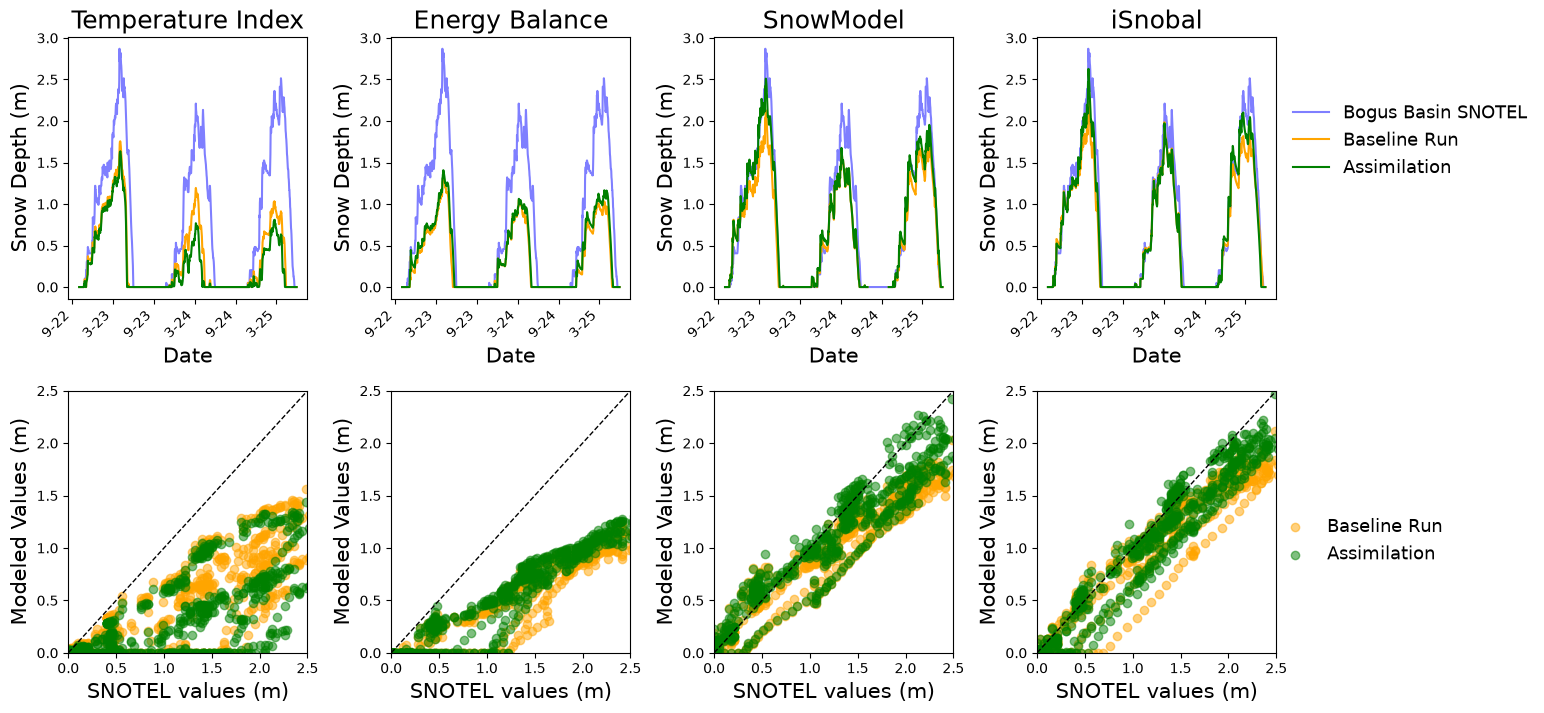

In [21]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

def mmyy_no_leading_zero(x, pos):
    date = mdates.num2date(x)
    return f"{date.month}-{date.strftime('%y')}"

##Plots for BB
obs = bb_ds['SNOWDEPTH (m)']
fcst1_a = bb_ds['HMS_TI_t1']
fcst1_b = bb_ds['HMS_TI_t2']

fcst2_a = bb_ds['HMS_EB_t1']
fcst2_b = bb_ds['HMS_EB_t2']

fcst3_a = bb_ds['SnowModel_t1']
fcst3_b = bb_ds['SnowModel_t2']

fcst4_a = bb_ds['iSnobal_t1']
fcst4_b = bb_ds['iSnobal_t2']

forecasts = [
    ("Temperature Index", fcst1_a, fcst1_b),
    ("Energy Balance", fcst2_a, fcst2_b),
    ("SnowModel", fcst3_a, fcst3_b),
    ("iSnobal", fcst4_a, fcst4_b),
]

fig, axs = plt.subplots(2, 4, figsize=(16, 8))

for i, (name, fcst_a, fcst_b) in enumerate(forecasts):

    obs.plot(ax=axs[0, i], label="Bogus Basin SNOTEL", color="blue", alpha=0.5)
    fcst_a.plot(ax=axs[0, i], label="Baseline Run", color="orange")
    fcst_b.plot(ax=axs[0, i], label="Assimilation", color="green")

    axs[0, i].set_ylabel("Snow Depth (m)", fontsize=15)
    axs[0, i].set_xlabel("Date", fontsize=15)

    axs[0, i].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    axs[0, i].xaxis.set_major_formatter(FuncFormatter(mmyy_no_leading_zero))

    for label in axs[0, i].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

    # Scatter plot

    axs[1, i].scatter(
        obs.values,
        fcst_a.values,
        label="Baseline Run",
        alpha=0.5,
        color='orange'
    )

    axs[1, i].scatter(
        obs.values,
        fcst_b.values,
        label="Assimilation",
        alpha=0.5,
        color='green'
    )

    axs[1, i].plot(
        [0, 2.5],
        [0, 2.5],
        color="black",
        linestyle="--",
        linewidth=1
    )

    axs[1, i].set_xlabel("SNOTEL values (m)", fontsize=15)
    axs[1, i].set_ylabel("Modeled Values (m)", fontsize=15)
    axs[1, i].set_xlim(0, 2.5)
    axs[1, i].set_ylim(0, 2.5)

    kge1 = kge(fcst_a, obs, include_components=True)
    kge2 = kge(fcst_b, obs, include_components=True)

    axs[0, i].set_title(f"{name}", fontsize=18)

# --- One legend per row, pinned outside the rightmost column ---
fig.subplots_adjust(right=0.88, wspace=0.35, hspace=0.35)

handles0, labels0 = axs[0, -1].get_legend_handles_labels()
leg0 = fig.legend(handles0, labels0, loc='center left',
                   bbox_to_anchor=(0.88, 0.75), fontsize=13, frameon=False)

handles1, labels1 = axs[1, -1].get_legend_handles_labels()
leg1 = fig.legend(handles1, labels1, loc='center left',
                   bbox_to_anchor=(0.87, 0.25), fontsize=13, frameon=False)

# plt.savefig(
#     'C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/KGE_BB_presentation.png',
#     dpi=300,
#     bbox_inches='tight',
#     bbox_extra_artists=(leg0, leg1)
# )
plt.show()

In [22]:
rows_list = []

for i, (name, fcst_a, fcst_b) in enumerate(forecasts):
    kge1 = kge(fcst_a, obs, include_components=True)
    kge2 = kge(fcst_b, obs, include_components=True)

    nse1 = nse(fcst_a, obs)
    nse2 = nse(fcst_b, obs)

    rows_list.append({
        "Model Run": name,
        "Baseline KGE": f"{kge1['kge'].item():.3f}",
        "Assimilation KGE": f"{kge2['kge'].item():.3f}",
        "Baseline NSE": f"{nse1.item():.3f}",
        "Assimilation NSE": f"{nse2.item():.3f}",
        "Baseline bias": f"{kge1['beta'].item():.3f}",
        "Assimilation bias": f"{kge2['beta'].item():.3f}",
    })

stats_df = pd.DataFrame(rows_list)
print(stats_df)

           Model Run Baseline KGE Assimilation KGE Baseline NSE  \
0  Temperature Index        0.264            0.125        0.138   
1     Energy Balance        0.224            0.286        0.184   
2          SnowModel        0.663            0.804        0.831   
3            iSnobal        0.738            0.833        0.877   

  Assimilation NSE Baseline bias Assimilation bias  
0           -0.175         0.430             0.330  
1            0.317         0.419             0.469  
2            0.904         0.790             0.893  
3            0.930         0.824             0.875  
